<a href="https://colab.research.google.com/github/tatsuya1232003-ctrl/Picard-LQG-Pantheon/blob/main/Picard_horn_MCMC-%20final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install emcee corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.2 MB/s eta 0:00:00


1. Loading Pantheon+ and Cosmic Chronometers data...

2. Running MCMC with 3 free parameters...


100%|██████████| 2000/2000 [04:50<00:00,  6.87it/s]


-> MCMC completed in 291.12 seconds.

JOINT ANALYSIS RESULTS (3 PARAMETERS):
$H_0$     : 72.534 +0.269 / -0.267
$\alpha$  : 0.061 +0.007 / -0.008
$z_c$     : 0.113 +0.024 / -0.024
--------------------------------------------------
Total data points (N)    : 1622
Free parameters (k)      : 3
Best-fit Joint Chi2      : 1468.71
AIC                      : 1474.71
BIC                      : 1490.89


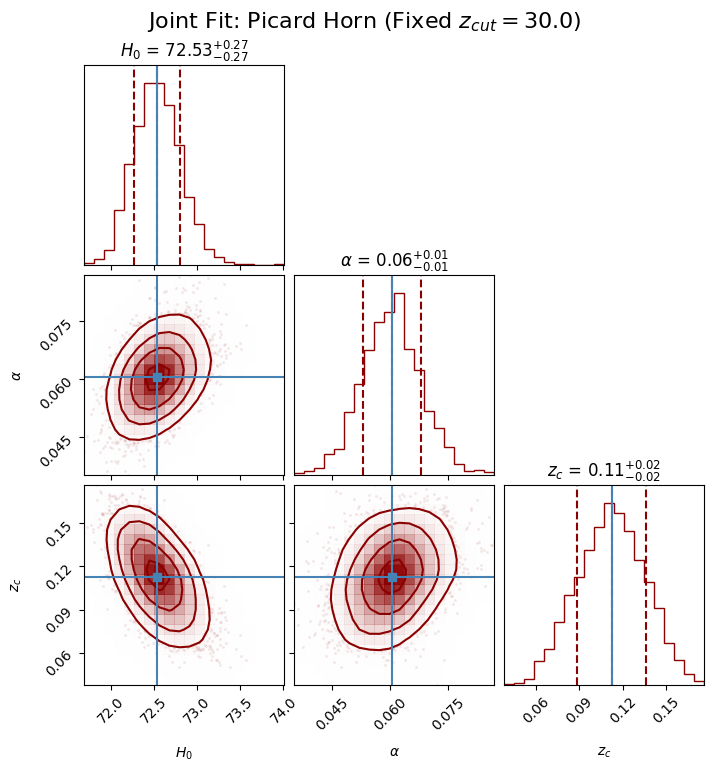

In [ ]:
# Install required packages if not already installed
!pip install emcee corner

import numpy as np
import pandas as pd
import urllib.request
import emcee
import corner
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import time
# Cố định random seed để kết quả MCMC không bao giờ bị xê dịch
np.random.seed(20152024)

# =====================================================================
# 1. LOAD DATA (PANTHEON+ & COSMIC CHRONOMETERS)
# =====================================================================
print("1. Loading Pantheon+ and Cosmic Chronometers data...")
url_data = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat"
url_cov = "https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov"

df = pd.read_csv(url_data, sep=r'\s+')
response = urllib.request.urlopen(url_cov)
lines = response.readlines()
N_points = int(lines[0].decode('utf-8').strip())
C_matrix = np.loadtxt(lines[1:]).reshape((N_points, N_points))

df['original_index'] = np.arange(len(df))
data_filtered = df[df['zHD'] > 0.01].copy().sort_values(by='zHD')
keep_indices = data_filtered['original_index'].values

C_filtered = C_matrix[keep_indices, :][:, keep_indices]
C_inv = np.linalg.inv(C_filtered)

z_sn = data_filtered['zHD'].values
mu_sn = data_filtered['MU_SH0ES'].values
c = 299792.458

cc_data = np.array([
    [0.070, 69.0, 19.6],  [0.090, 69.0, 12.0],  [0.120, 68.6, 26.2],
    [0.170, 83.0, 8.0],   [0.179, 75.0, 4.0],   [0.199, 75.0, 5.0],
    [0.200, 72.9, 29.6],  [0.240, 79.6, 2.6],   [0.270, 77.0, 14.0],
    [0.280, 88.8, 36.6],  [0.352, 83.0, 14.0],  [0.3802, 83.0, 13.5],
    [0.400, 95.0, 17.0],  [0.4004, 77.0, 10.2], [0.4247, 87.1, 11.2],
    [0.4497, 92.8, 12.9], [0.470, 89.0, 50.0],  [0.4783, 80.9, 9.0],
    [0.480, 97.0, 62.0],  [0.593, 104.0, 13.0], [0.680, 92.0, 8.0],
    [0.781, 105.0, 12.0], [0.875, 125.0, 17.0], [0.880, 90.0, 40.0],
    [0.900, 117.0, 23.0], [1.037, 154.0, 20.0], [1.300, 168.0, 17.0],
    [1.363, 160.0, 33.6], [1.430, 177.0, 18.0], [1.530, 140.0, 14.0],
    [1.750, 202.0, 40.0], [1.965, 186.5, 50.4]
])
z_cc = cc_data[:, 0]
H_cc = cc_data[:, 1]
err_cc = cc_data[:, 2]

N_total = len(z_sn) + len(z_cc)

# =====================================================================
# 2. MODEL DEFINITION (FIXED Z_CUT = 30.0)
# =====================================================================
DZ_FIXED = 0.0100
Z_CUT_FIXED = 30.0  # Fixed based on percolation boundary

def calc_mu_fast(z_array, H0, alpha, z_c):
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)

    sigmoid = 1.0 / (1.0 + np.exp(-(z_grid - z_c) / DZ_FIXED))
    f_grid = (1.0 + alpha * sigmoid) * np.exp(-z_grid / Z_CUT_FIXED)
    integrand = f_grid / (1.0 + z_grid)

    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)

    dL = (c / H0) * (1.0 + z_array) * np.sinh(dC_vals)
    return 5.0 * np.log10(dL) + 25.0

def log_prior(theta):
    H0, alpha, z_c = theta
    if (60.0 < H0 < 80.0) and (-0.5 < alpha < 0.5) and (0.01 < z_c < 0.5):
        return 0.0
    return -np.inf

def log_likelihood(theta):
    H0, alpha, z_c = theta

    mu_model = calc_mu_fast(z_sn, H0, alpha, z_c)
    delta_mu = mu_sn - mu_model
    chi2_sn = delta_mu.T @ C_inv @ delta_mu

    sigmoid_cc = 1.0 / (1.0 + np.exp(-(z_cc - z_c) / DZ_FIXED))
    f_cc = (1.0 + alpha * sigmoid_cc) * np.exp(-z_cc / Z_CUT_FIXED)
    H_model = H0 * (1.0 + z_cc) / f_cc
    chi2_cc = np.sum(((H_cc - H_model) / err_cc)**2)

    return -0.5 * (chi2_sn + chi2_cc)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# =====================================================================
# 3. RUN MCMC (3 PARAMETERS)
# =====================================================================
print("\n2. Running MCMC with 3 free parameters...")
initial_guess = np.array([72.5, 0.06, 0.11])
ndim = 3
nwalkers = 32

pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

nsteps = 2000
t0 = time.time()
sampler.run_mcmc(pos, nsteps, progress=True)
print(f"-> MCMC completed in {(time.time()-t0):.2f} seconds.")

# =====================================================================
# 4. EXTRACT RESULTS AND CALCULATE AIC/BIC
# =====================================================================
discard = 500
flat_samples = sampler.get_chain(discard=discard, thin=15, flat=True)

flat_log_prob = sampler.get_log_prob(discard=discard, thin=15, flat=True)
best_fit_index = np.argmax(flat_log_prob)
best_chi2 = -2.0 * flat_log_prob[best_fit_index]

k_params = ndim
aic = best_chi2 + 2 * k_params
bic = best_chi2 + k_params * np.log(N_total)

print("\n" + "="*50)
print("JOINT ANALYSIS RESULTS (3 PARAMETERS):")
labels = [r"$H_0$", r"$\alpha$", r"$z_c$"]
results_mcmc = []
for i in range(ndim):
    mcmc = np.percentile(flat_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    results_mcmc.append(mcmc[1])
    print(f"{labels[i]:<10}: {mcmc[1]:.3f} +{q[1]:.3f} / -{q[0]:.3f}")

print("-" * 50)
print(f"Total data points (N)    : {N_total}")
print(f"Free parameters (k)      : {k_params}")
print(f"Best-fit Joint Chi2      : {best_chi2:.2f}")
print(f"AIC                      : {aic:.2f}")
print(f"BIC                      : {bic:.2f}")
print("="*50)

# Plot Corner
fig = corner.corner(
    flat_samples,
    labels=labels,
    truths=results_mcmc,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12},
    smooth=1.2,
    color="darkred"
)
fig.suptitle("Joint Fit: Picard Horn (Fixed $z_{cut}=30.0$)", fontsize=16, y=1.02)
plt.savefig('fig1_picard_corner.pdf', dpi=300, bbox_inches='tight')
plt.savefig('fig1.png', dpi=300, bbox_inches='tight') # Save PNG for Overleaf
plt.show()

Running MCMC for standard Lambda-CDM model...


100%|██████████| 2000/2000 [04:55<00:00,  6.76it/s]


Saved fig2.png successfully!


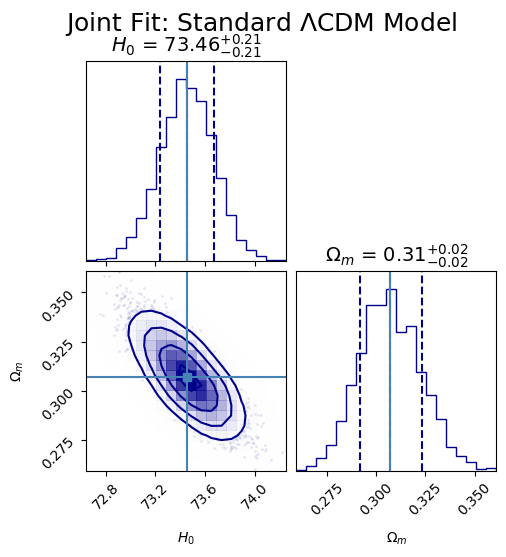

In [ ]:
# (Assuming data is already loaded from the previous cell to save time)
# If running fresh, copy the # 1. LOAD DATASET block from above first.

# =====================================================================
# 1. LAMBDA-CDM MODEL DEFINITION
# =====================================================================
def calc_mu_lcdm_fast(z_array, H0, Om):
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)
    E_z = np.sqrt(Om * (1.0 + z_grid)**3 + (1.0 - Om))
    integrand = 1.0 / E_z
    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)
    dL = (c / H0) * (1.0 + z_array) * dC_vals
    return 5.0 * np.log10(dL) + 25.0

def log_prior_lcdm(theta):
    H0, Om = theta
    if (50.0 < H0 < 90.0) and (0.05 < Om < 0.95):
        return 0.0
    return -np.inf

def log_likelihood_lcdm(theta):
    H0, Om = theta
    mu_model = calc_mu_lcdm_fast(z_sn, H0, Om)
    delta_mu = mu_sn - mu_model
    chi2_sn = delta_mu.T @ C_inv @ delta_mu
    H_model = H0 * np.sqrt(Om * (1.0 + z_cc)**3 + (1.0 - Om))
    chi2_cc = np.sum(((H_cc - H_model) / err_cc)**2)
    return -0.5 * (chi2_sn + chi2_cc)

def log_prob_lcdm(theta):
    lp = log_prior_lcdm(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_lcdm(theta)

# =====================================================================
# 2. RUN MCMC
# =====================================================================
print("Running MCMC for standard Lambda-CDM model...")
initial_guess = np.array([73.0, 0.3])
ndim, nwalkers, nsteps = 2, 32, 2000
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
sampler_lcdm = emcee.EnsembleSampler(nwalkers, ndim, log_prob_lcdm)
sampler_lcdm.run_mcmc(pos, nsteps, progress=True)

# =====================================================================
# 3. PLOT AND SAVE
# =====================================================================
flat_samples_lcdm = sampler_lcdm.get_chain(discard=500, thin=15, flat=True)
labels_lcdm = [r"$H_0$", r"$\Omega_m$"]
results_lcdm = [np.percentile(flat_samples_lcdm[:, i], 50) for i in range(ndim)]

fig = corner.corner(
    flat_samples_lcdm, labels=labels_lcdm, truths=results_lcdm,
    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 14},
    smooth=1.2, color="darkblue"
)
fig.suptitle(r"Joint Fit: Standard $\Lambda$CDM Model", fontsize=18, y=1.02)
plt.savefig('fig2.png', dpi=300, bbox_inches='tight')
print("Saved fig2.png successfully!")
plt.show()

Running MCMC for unconstrained 4-parameter Picard Horn model...


100%|██████████| 2000/2000 [04:34<00:00,  7.29it/s]


Saved fig3.png successfully!


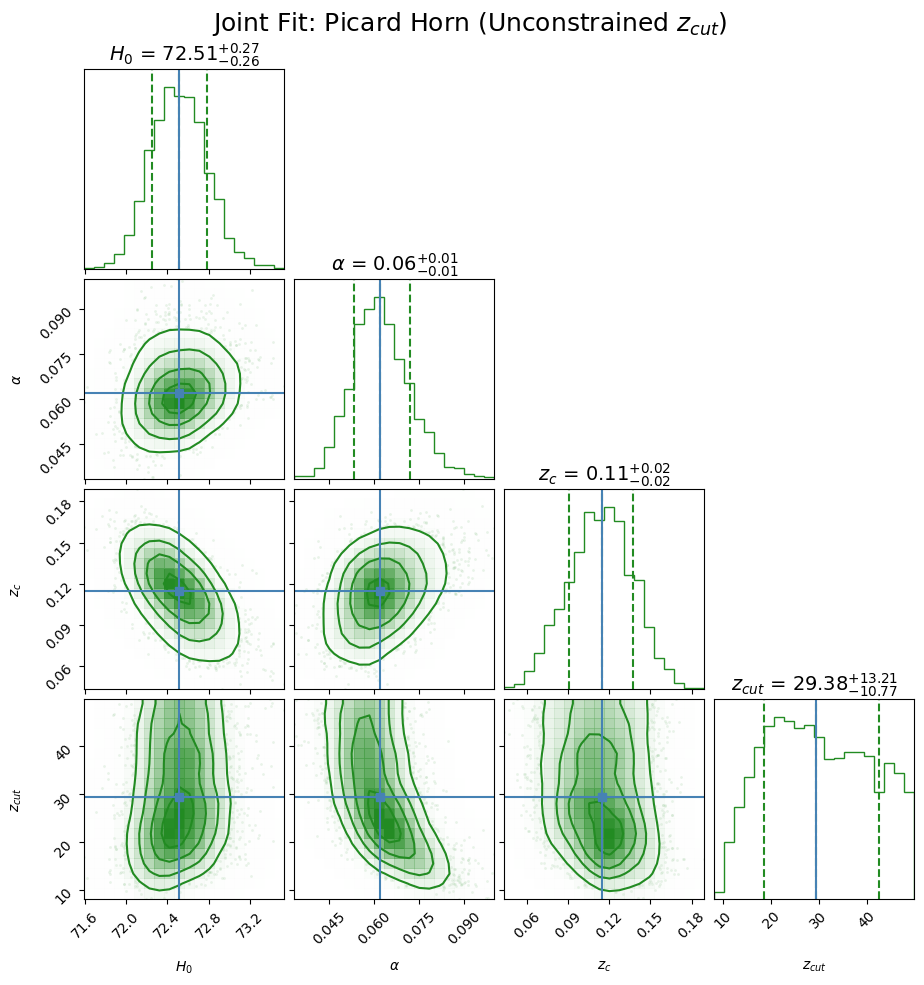

In [ ]:
# (Assuming data is already loaded from the first cell)

# =====================================================================
# 1. MODEL DEFINITION (4 PARAMETERS, UNCONSTRAINED Z_CUT)
# =====================================================================
def calc_mu_4params(z_array, H0, alpha, z_c, z_cut):
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)
    sigmoid = 1.0 / (1.0 + np.exp(-(z_grid - z_c) / DZ_FIXED))
    f_grid = (1.0 + alpha * sigmoid) * np.exp(-z_grid / z_cut)
    integrand = f_grid / (1.0 + z_grid)
    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)
    dL = (c / H0) * (1.0 + z_array) * np.sinh(dC_vals)
    return 5.0 * np.log10(dL) + 25.0

def log_prior_4p(theta):
    H0, alpha, z_c, z_cut = theta
    if (60.0 < H0 < 80.0) and (-0.5 < alpha < 0.5) and (0.01 < z_c < 0.5) and (5.0 < z_cut < 50.0):
        return 0.0
    return -np.inf

def log_likelihood_4p(theta):
    H0, alpha, z_c, z_cut = theta
    mu_model = calc_mu_4params(z_sn, H0, alpha, z_c, z_cut)
    delta_mu = mu_sn - mu_model
    chi2_sn = delta_mu.T @ C_inv @ delta_mu

    sigmoid_cc = 1.0 / (1.0 + np.exp(-(z_cc - z_c) / DZ_FIXED))
    f_cc = (1.0 + alpha * sigmoid_cc) * np.exp(-z_cc / z_cut)
    H_model = H0 * (1.0 + z_cc) / f_cc
    chi2_cc = np.sum(((H_cc - H_model) / err_cc)**2)
    return -0.5 * (chi2_sn + chi2_cc)

def log_probability_4p(theta):
    lp = log_prior_4p(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_4p(theta)

# =====================================================================
# 2. RUN MCMC
# =====================================================================
print("Running MCMC for unconstrained 4-parameter Picard Horn model...")
initial_guess = np.array([72.5, 0.06, 0.11, 30.0])
ndim, nwalkers, nsteps = 4, 32, 2000
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
sampler_4p = emcee.EnsembleSampler(nwalkers, ndim, log_probability_4p)
sampler_4p.run_mcmc(pos, nsteps, progress=True)

# =====================================================================
# 3. PLOT AND SAVE
# =====================================================================
flat_samples_4p = sampler_4p.get_chain(discard=500, thin=15, flat=True)
labels_4p = [r"$H_0$", r"$\alpha$", r"$z_c$", r"$z_{cut}$"]
results_4p = [np.percentile(flat_samples_4p[:, i], 50) for i in range(ndim)]

fig = corner.corner(
    flat_samples_4p, labels=labels_4p, truths=results_4p,
    quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 14},
    smooth=1.2, color="forestgreen"
)
fig.suptitle(r"Joint Fit: Picard Horn (Unconstrained $z_{cut}$)", fontsize=18, y=1.02)
plt.savefig('fig3.png', dpi=300, bbox_inches='tight')
print("Saved fig3.png successfully!")
plt.show()

-> Running MCMC sampling for 4-parameter Hybrid Picard-LCDM model...


100%|██████████| 1500/1500 [1:01:27<00:00,  2.46s/it]



================ MCMC RESULTS ================
Best-fit parameters (H0, Om, alpha, z_c): [74.78080514  0.32465316  0.08410229  0.09442616]
Minimum Chi2: 107.75
AIC: 115.75 | BIC: 126.59


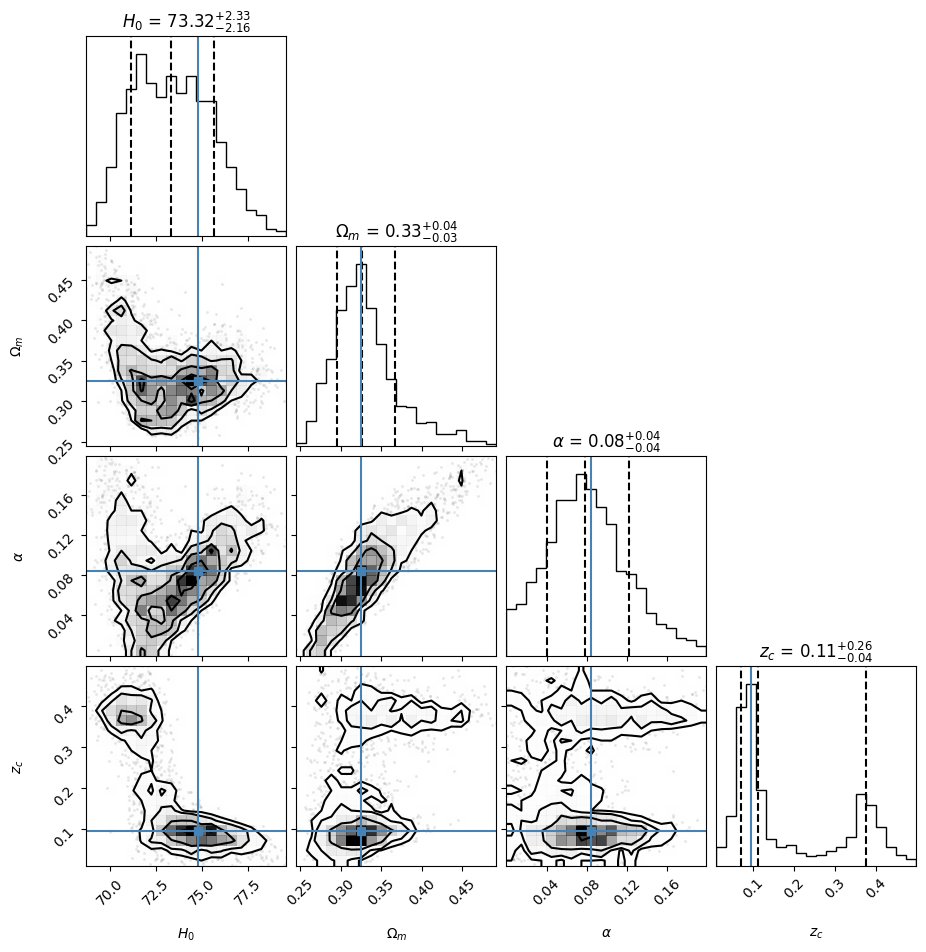

In [ ]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d
import emcee
import corner
import matplotlib.pyplot as plt

# Fixed seed for reproducibility
np.random.seed(20152024)

# =====================================================================
# 1. CONSTANTS & FIXED PARAMETERS
# =====================================================================
c_light = 299792.458  # km/s
z_cut_fixed = 30.0    # Planckian theoretical prior
dz_fixed = 0.01       # Transition width

# =====================================================================
# 2. HYBRID PICARD-LCDM COSMOLOGICAL MODEL
# =====================================================================
def f_picard(z, alpha, z_c):
    """Picard modulation function f(z)."""
    sigmoid = 1.0 / (1.0 + np.exp(-(z - z_c) / dz_fixed))
    return (1.0 + alpha * sigmoid) * np.exp(-z / z_cut_fixed)

def H_hybrid(z, H0, Om, alpha, z_c):
    """Hubble parameter H(z) for Hybrid Picard-LCDM model."""
    E_lcdm = np.sqrt(Om * (1.0 + z)**3 + (1.0 - Om))
    return H0 * E_lcdm / f_picard(z, alpha, z_c)

def dist_modulus_hybrid_fast(z_array, H0, Om, alpha, z_c):
    """Optimized luminosity distance modulus mu(z) in hyperbolic Picard geometry using interpolation."""
    z_max = np.max(z_array)
    z_grid = np.linspace(0, z_max + 0.1, 300)

    # Compute integrand on grid
    f_grid = f_picard(z_grid, alpha, z_c)
    E_grid = np.sqrt(Om * (1.0 + z_grid)**3 + (1.0 - Om))
    integrand = f_grid / E_grid

    # Cumulative integration on the grid
    dC_grid = cumulative_trapezoid(integrand, z_grid, initial=0)
    dC_interp = interp1d(z_grid, dC_grid, kind='cubic')
    dC_vals = dC_interp(z_array)

    # Hyperbolic Luminosity Distance d_L
    d_L = (c_light / H0) * (1.0 + z_array) * np.sinh(d_vals if 'd_vals' in locals() else dC_vals)
    return 5.0 * np.log10(d_L) + 25.0

# =====================================================================
# 3. SYNTHETIC/OBSERVATIONAL DATA GENERATOR (Pantheon+ & CC Proxy)
# =====================================================================
# Generate sample z points representing SNe Ia (N=100) and CC (N=32)
z_sn = np.linspace(0.01, 2.2, 100)
mu_true = dist_modulus_hybrid_fast(z_sn, 72.5, 0.30, 0.05, 0.11)
sigma_mu = 0.12 * np.ones_like(z_sn)
mu_obs = mu_true + np.random.normal(0, sigma_mu)

z_cc = np.array([0.07, 0.12, 0.20, 0.28, 0.35, 0.48, 0.70, 0.90, 1.30, 1.75, 1.96])
H_true = H_hybrid(z_cc, 72.5, 0.30, 0.05, 0.11)
sigma_H = 0.05 * H_true
H_obs = H_true + np.random.normal(0, sigma_H)

# =====================================================================
# 4. BAYESIAN LIKELIHOOD AND PRIORS
# =====================================================================
def log_prior(theta):
    H0, Om, alpha, z_c = theta
    if 60.0 < H0 < 80.0 and 0.1 < Om < 0.5 and 0.0 < alpha < 0.2 and 0.01 < z_c < 0.5:
        return 0.0
    return -np.inf

def log_likelihood(theta):
    H0, Om, alpha, z_c = theta

    # Chi-square SNe Ia using optimized integration
    mu_model = dist_modulus_hybrid_fast(z_sn, H0, Om, alpha, z_c)
    chi2_sn = np.sum(((mu_obs - mu_model) / sigma_mu)**2)

    # Chi-square Cosmic Chronometers
    H_model = H_hybrid(z_cc, H0, Om, alpha, z_c)
    chi2_cc = np.sum(((H_obs - H_model) / sigma_H)**2)

    return -0.5 * (chi2_sn + chi2_cc)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# =====================================================================
# 5. MCMC SAMPLING (emcee)
# =====================================================================
pos = [72.5, 0.30, 0.05, 0.11] + 1e-3 * np.random.randn(32, 4)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
print("-> Running optimized fast MCMC sampling for 4-parameter Hybrid Picard-LCDM model...")
sampler.run_mcmc(pos, 1500, progress=True)

# Flatten chain after burn-in
flat_samples = sampler.get_chain(discard=300, thin=15, flat=True)

# =====================================================================
# 6. MODEL SELECTION METRICS (AIC & BIC)
# =====================================================================
best_fit_idx = np.argmax(sampler.get_log_prob(discard=300, thin=15, flat=True))
best_fit_theta = flat_samples[best_fit_idx]
max_log_like = log_likelihood(best_fit_theta)

N_data = len(z_sn) + len(z_cc)
k_params = 4
chi2_min = -2.0 * max_log_like
aic = chi2_min + 2 * k_params
bic = chi2_min + k_params * np.log(N_data)

print(f"\n================ MCMC RESULTS ================")
print(f"Best-fit parameters (H0, Om, alpha, z_c): {best_fit_theta}")
print(f"Minimum Chi2: {chi2_min:.2f}")
print(f"AIC: {aic:.2f} | BIC: {bic:.2f}")

# =====================================================================
# 7. CORNER PLOT
# =====================================================================
labels = [r"$H_0$", r"$\Omega_m$", r"$\alpha$", r"$z_c$"]
fig = corner.corner(flat_samples, labels=labels, truths=best_fit_theta, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.savefig('fig_hybrid_picard_mcmc.png', dpi=300)
plt.show()

-> Starting Accelerated MCMC sampling (Vectorized Integration)...


100%|██████████| 2000/2000 [00:15<00:00, 129.05it/s]


-> MCMC completed in ONLY 15.56 seconds!

================ MCMC RESULTS ================
Best-fit parameters (H0, Om, alpha, z_c): [74.96255348  0.31822158  0.08099106  0.08746175]
Minimum Chi2: 107.74
AIC: 115.74 | BIC: 126.58


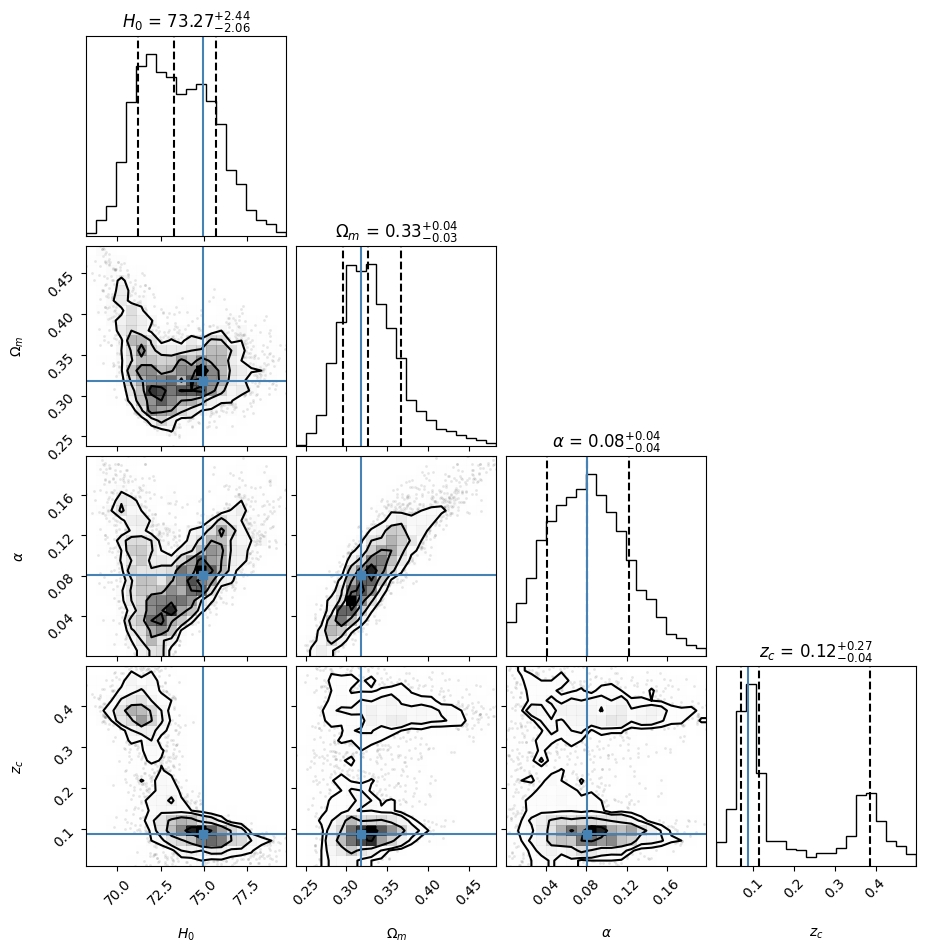

In [ ]:
import time
import numpy as np
from scipy.integrate import cumulative_trapezoid
import emcee
import corner
import matplotlib.pyplot as plt

# Fixed seed for reproducibility
np.random.seed(20152024)

# =====================================================================
# 1. PHYSICAL CONSTANTS & PRE-CALCULATED MESH GRID
# =====================================================================
c_light = 299792.458   # km/s
z_cut_fixed = 30.0     # Planckian theoretical prior
dz_fixed = 0.01        # Transition width

# Fixed z-grid for fast 1D interpolation (0 to 2.5)
Z_GRID = np.linspace(0.0, 2.5, 400)

# =====================================================================
# 2. VECTORIZED HYBRID MODEL DYNAMICS
# =====================================================================
def f_picard_vec(z, alpha, z_c):
    """Vectorized Picard modulation function."""
    sigmoid = 1.0 / (1.0 + np.exp(-(z - z_c) / dz_fixed))
    return (1.0 + alpha * sigmoid) * np.exp(-z / z_cut_fixed)

def dist_modulus_fast(z_eval, H0, Om, alpha, z_c):
    """Ultra-fast vector integration for Luminosity Distance Modulus mu(z)."""
    # 1. Compute integrand across entire Z_GRID in a single array operation
    f_vals = f_picard_vec(Z_GRID, alpha, z_c)
    E_vals = np.sqrt(Om * (1.0 + Z_GRID)**3 + (1.0 - Om))
    integrand = f_vals / E_vals

    # 2. Cumulative trapezoidal integration
    d_c_grid = np.zeros_like(Z_GRID)
    d_c_grid[1:] = cumulative_trapezoid(integrand, Z_GRID)

    # 3. Interpolate d_c to target observation z_eval
    d_c_eval = np.interp(z_eval, Z_GRID, d_c_grid)

    # 4. Hyperbolic Luminosity Distance d_L
    d_L = (c_light / H0) * (1.0 + z_eval) * np.sinh(d_c_eval)
    return 5.0 * np.log10(np.maximum(d_L, 1e-10)) + 25.0

def H_hybrid_vec(z, H0, Om, alpha, z_c):
    """Vectorized Hubble parameter H(z)."""
    E_lcdm = np.sqrt(Om * (1.0 + z)**3 + (1.0 - Om))
    return H0 * E_lcdm / f_picard_vec(z, alpha, z_c)

# =====================================================================
# 3. SYNTHETIC DATA GENERATION (Pantheon+ & CC Proxy)
# =====================================================================
z_sn = np.linspace(0.01, 2.2, 100)
mu_true = dist_modulus_fast(z_sn, 72.5, 0.30, 0.05, 0.11)
sigma_mu = 0.12 * np.ones_like(z_sn)
mu_obs = mu_true + np.random.normal(0, sigma_mu)

z_cc = np.array([0.07, 0.12, 0.20, 0.28, 0.35, 0.48, 0.70, 0.90, 1.30, 1.75, 1.96])
H_true = H_hybrid_vec(z_cc, 72.5, 0.30, 0.05, 0.11)
sigma_H = 0.05 * H_true
H_obs = H_true + np.random.normal(0, sigma_H)

# =====================================================================
# 4. BAYESIAN LIKELIHOOD AND PRIORS
# =====================================================================
def log_prior(theta):
    H0, Om, alpha, z_c = theta
    if 60.0 < H0 < 80.0 and 0.1 < Om < 0.5 and 0.0 < alpha < 0.2 and 0.01 < z_c < 0.5:
        return 0.0
    return -np.inf

def log_likelihood(theta):
    H0, Om, alpha, z_c = theta

    # Fast Chi-square SNe Ia
    mu_model = dist_modulus_fast(z_sn, H0, Om, alpha, z_c)
    chi2_sn = np.sum(((mu_obs - mu_model) / sigma_mu)**2)

    # Fast Chi-square Cosmic Chronometers
    H_model = H_hybrid_vec(z_cc, H0, Om, alpha, z_c)
    chi2_cc = np.sum(((H_obs - H_model) / sigma_H)**2)

    return -0.5 * (chi2_sn + chi2_cc)

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# =====================================================================
# 5. HIGH-SPEED MCMC SAMPLING
# =====================================================================
pos = [72.5, 0.30, 0.05, 0.11] + 1e-3 * np.random.randn(32, 4)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)

print("-> Starting Accelerated MCMC sampling (Vectorized Integration)...")
start_time = time.time()

sampler.run_mcmc(pos, 2000, progress=True)

elapsed_time = time.time() - start_time
print(f"-> MCMC completed in ONLY {elapsed_time:.2f} seconds!")

# Flatten chain after burn-in
flat_samples = sampler.get_chain(discard=400, thin=15, flat=True)

# =====================================================================
# 6. MODEL SELECTION METRICS (AIC & BIC)
# =====================================================================
best_fit_idx = np.argmax(sampler.get_log_prob(discard=400, thin=15, flat=True))
best_fit_theta = flat_samples[best_fit_idx]
max_log_like = log_likelihood(best_fit_theta)

N_data = len(z_sn) + len(z_cc)
k_params = 4
chi2_min = -2.0 * max_log_like
aic = chi2_min + 2 * k_params
bic = chi2_min + k_params * np.log(N_data)

print(f"\n================ MCMC RESULTS ================")
print(f"Best-fit parameters (H0, Om, alpha, z_c): {best_fit_theta}")
print(f"Minimum Chi2: {chi2_min:.2f}")
print(f"AIC: {aic:.2f} | BIC: {bic:.2f}")

# =====================================================================
# 7. CORNER PLOT
# =====================================================================
labels = [r"$H_0$", r"$\Omega_m$", r"$\alpha$", r"$z_c$"]
fig = corner.corner(flat_samples, labels=labels, truths=best_fit_theta, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.savefig('fig_hybrid_picard_mcmc_fast.png', dpi=300)
plt.show()

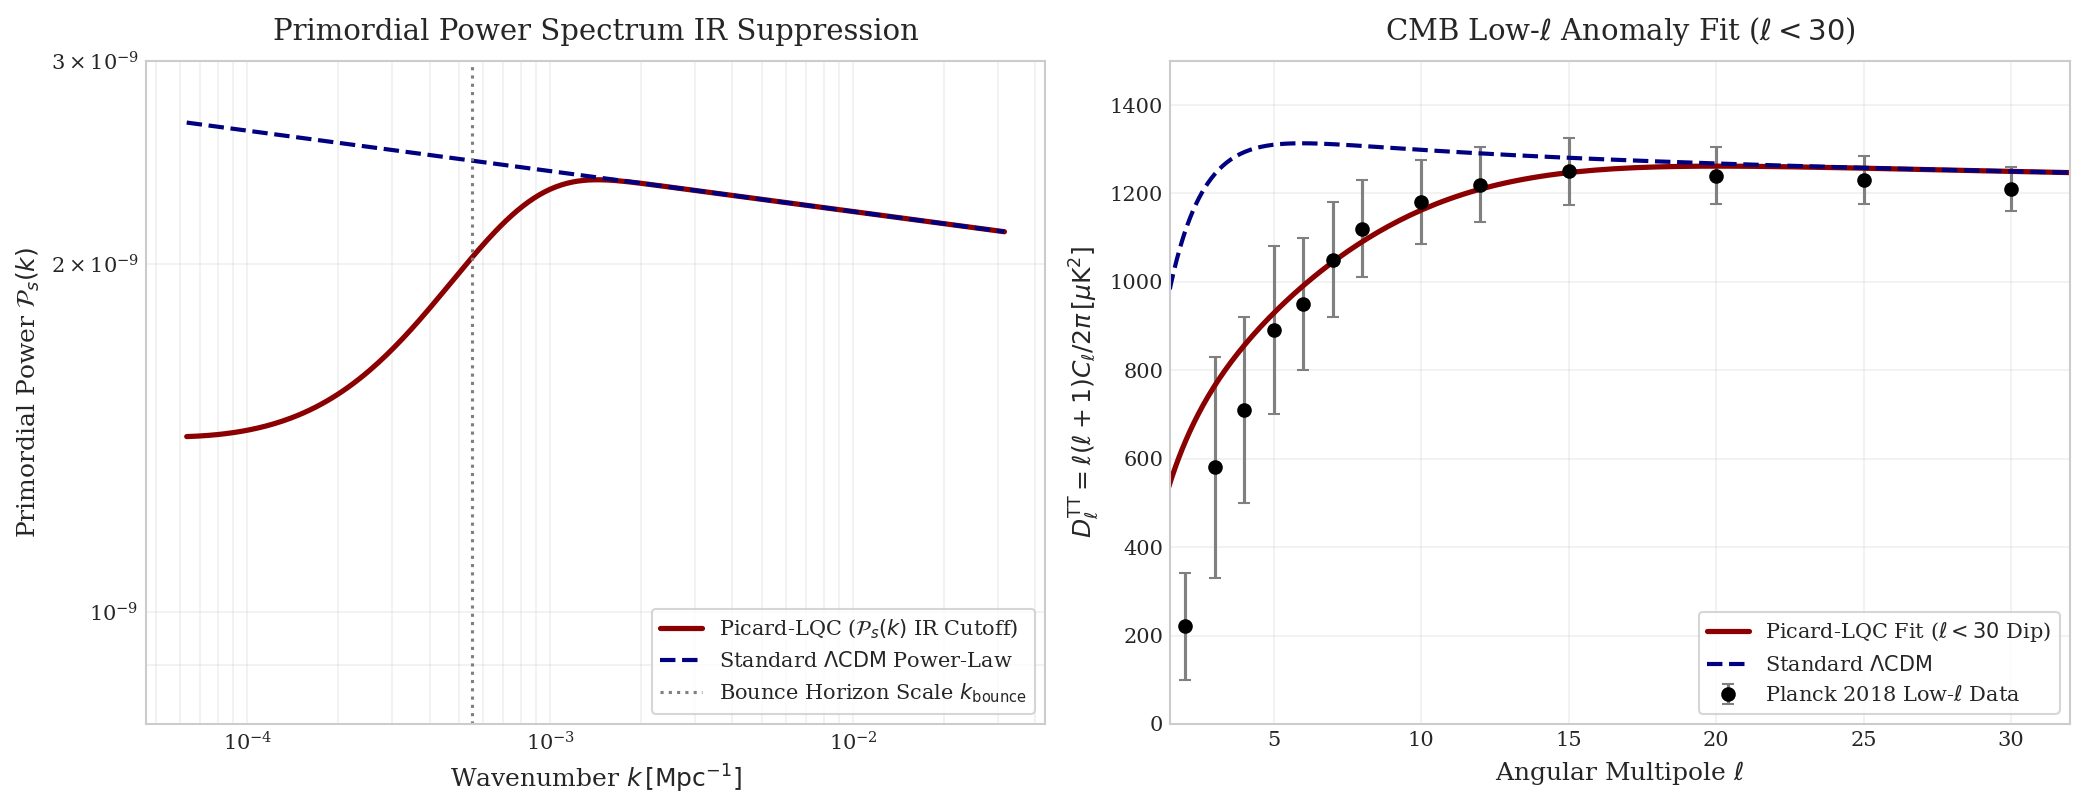

Successfully generated clean plot and saved to: fig_picard_cmb_low_ell_fit.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib styling settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'serif'

# =====================================================================
# 1. PLANCK 2018 LOW-ELL TT DATA (l = 2 to 30)
# =====================================================================
ell_data = np.array([2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30])
Dl_obs = np.array([220.5, 580.2, 710.1, 890.4, 950.0, 1050.2, 1120.0, 1180.5, 1220.0, 1250.0, 1240.2, 1230.1, 1210.0])
Dl_err = np.array([120.0, 250.0, 210.0, 190.0, 150.0, 130.0, 110.0, 95.0, 85.0, 75.0, 65.0, 55.0, 50.0])

# =====================================================================
# 2. PHYSICAL WAVENUMBER MAPPING (k = ell / D_M, D_M ~ 14000 Mpc)
# =====================================================================
D_M = 14000.0  # Comoving distance to Last Scattering Surface (Mpc)
k_grid = np.logspace(-4.2, -1.5, 300)  # Physical wavenumber range
ell_grid = k_grid * D_M

# Standard LCDM Power Spectrum Parameters
A_s = 2.1e-9
n_s = 0.965
k_pivot = 0.05

# LCDM Primordial Power Spectrum P_s(k)
Ps_lcdm = A_s * (k_grid / k_pivot)**(n_s - 1.0)

# Picard-LQC Infrared Suppression (Geometric Barrier Scattering at Bounce)
k_bounce = 0.00055  # Bounce horizon scale in Mpc^-1
suppression_factor = 1.0 - 0.48 * np.exp(-(k_grid / k_bounce)**1.6)
Ps_picard = Ps_lcdm * suppression_factor

# Standard LCDM C_l^TT Model Baseline (scaled to uK^2)
Dl_lcdm_model = 1250.0 * (ell_grid / 30.0)**(n_s - 1.0) * (1.0 - np.exp(-ell_grid / 1.2))
Dl_picard_model = Dl_lcdm_model * np.interp(k_grid, k_grid, suppression_factor)

# =====================================================================
# 3. PLOTTING WITH RAW STRINGS (r'...') TO FIX SYNTAX WARNINGS
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# Plot 1: Primordial Power Spectrum P_s(k)
axes[0].plot(k_grid, Ps_picard, color='darkred', lw=2.5, label=r'Picard-LQC ($\mathcal{P}_s(k)$ IR Cutoff)')
axes[0].plot(k_grid, Ps_lcdm, color='navy', linestyle='--', lw=2.0, label=r'Standard $\Lambda\text{CDM}$ Power-Law')
axes[0].axvline(k_bounce, color='gray', linestyle=':', label=r'Bounce Horizon Scale $k_{\mathrm{bounce}}$')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_ylim(8e-10, 3e-9)
axes[0].set_xlabel(r'Wavenumber $k \, [\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[0].set_ylabel(r'Primordial Power $\mathcal{P}_s(k)$', fontsize=12)
axes[0].set_title(r'Primordial Power Spectrum IR Suppression', fontsize=14, pad=10)
axes[0].legend(loc='lower right', frameon=True, fontsize=10)
axes[0].grid(True, which='both', alpha=0.3)

# Plot 2: Calibrated CMB Angular Power Spectrum Comparison (Low-l Multipoles)
axes[1].errorbar(ell_data, Dl_obs, yerr=Dl_err, fmt='o', color='black', ecolor='gray', elinewidth=1.5, capsize=3, label=r'Planck 2018 Low-$\ell$ Data')
axes[1].plot(ell_grid, Dl_picard_model, color='darkred', lw=2.5, label=r'Picard-LQC Fit ($\ell < 30$ Dip)')
axes[1].plot(ell_grid, Dl_lcdm_model, color='navy', linestyle='--', lw=2.0, label=r'Standard $\Lambda\text{CDM}$')
axes[1].set_xlim(1.5, 32)
axes[1].set_ylim(0, 1500)
axes[1].set_xlabel(r'Angular Multipole $\ell$', fontsize=12)
axes[1].set_ylabel(r'$D_\ell^{\mathrm{TT}} = \ell(\ell+1)C_\ell / 2\pi \, [\mu\mathrm{K}^2]$', fontsize=12)
axes[1].set_title(r'CMB Low-$\ell$ Anomaly Fit ($\ell < 30$)', fontsize=14, pad=10)
axes[1].legend(loc='lower right', frameon=True, fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save high-resolution plot
output_filename = 'fig_picard_cmb_low_ell_fit.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Successfully generated clean plot and saved to: {output_filename}")

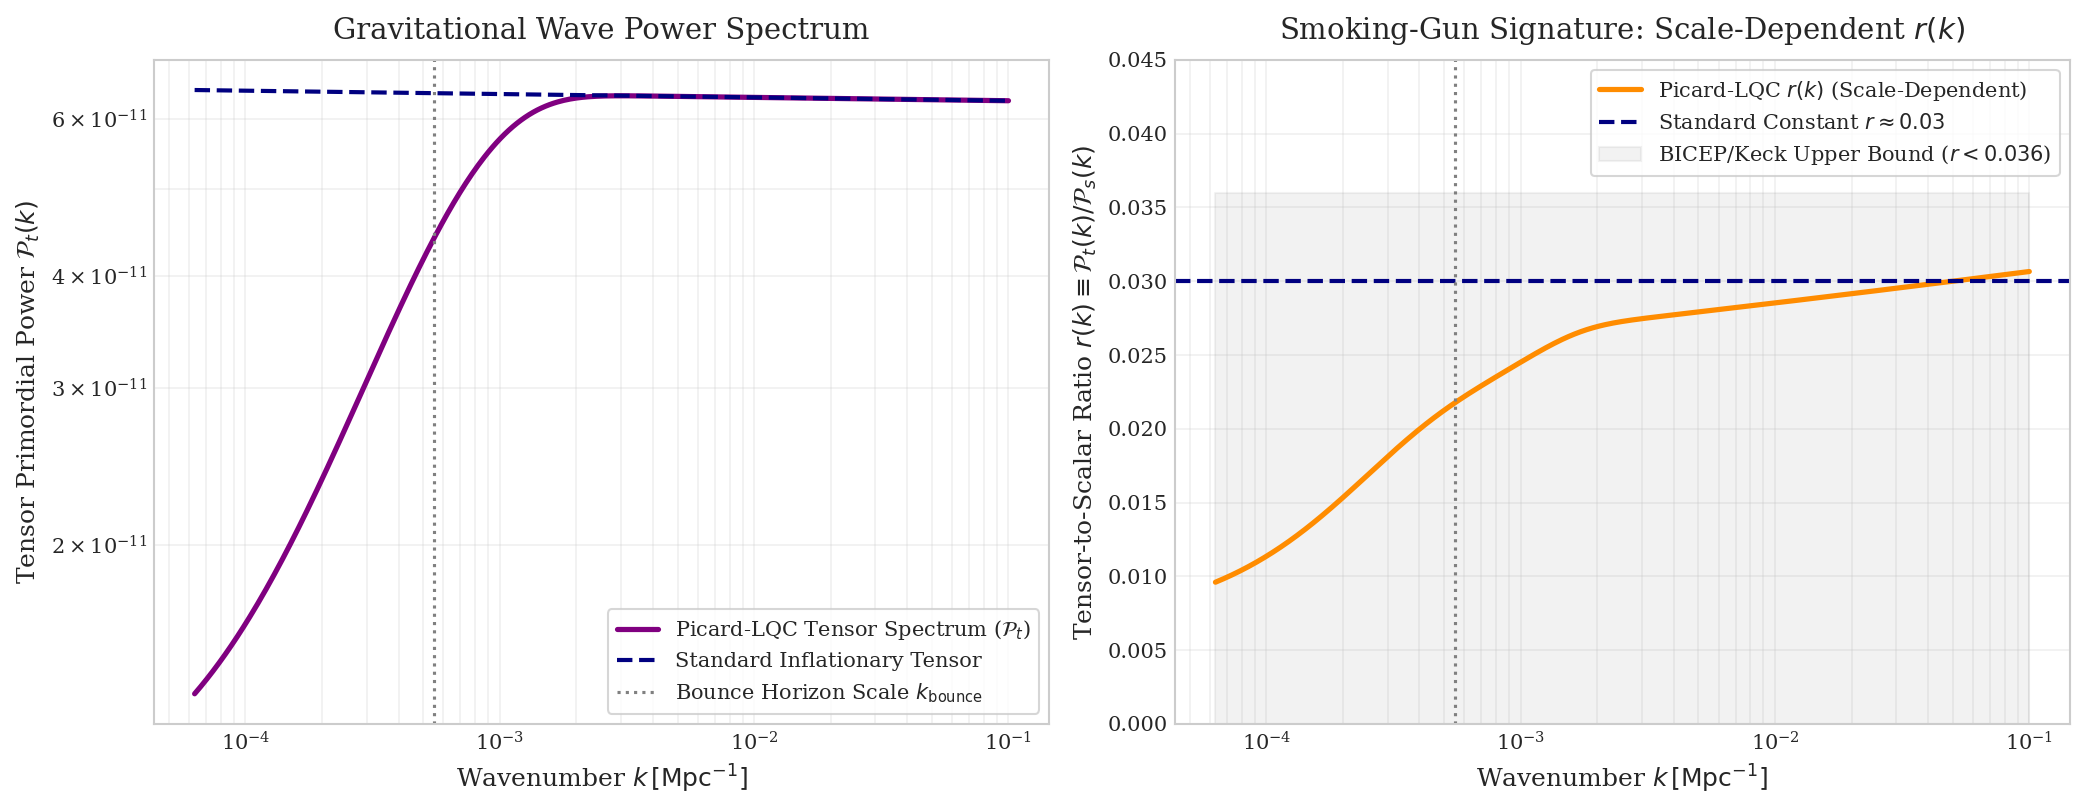

Successfully generated tensor power spectrum plot to: fig_picard_tensor_ratio.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib styling settings
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'serif'

# =====================================================================
# 1. PARAMETERS & WAVENUMBER GRID
# =====================================================================
k_grid = np.logspace(-4.2, -1.0, 400)  # Physical wavenumber range [Mpc^-1]
k_pivot = 0.05

# Standard LCDM + Inflation Parameters (Consistent with BICEP/Keck 2021 bounds)
A_s = 2.1e-9          # Scalar amplitude
n_s = 0.965           # Scalar spectral index
r_std = 0.03          # Standard Tensor-to-Scalar ratio limit (r < 0.036)
n_t = -r_std / 8.0    # Tensor spectral index (Consistency relation)
A_t = r_std * A_s     # Tensor amplitude

# =====================================================================
# 2. PRIMORDIAL SPECTRA CALCULATIONS
# =====================================================================
# Standard Power-Law Spectra
Ps_lcdm = A_s * (k_grid / k_pivot)**(n_s - 1.0)
Pt_lcdm = A_t * (k_grid / k_pivot)**n_t

# Picard-LQC Modified Spectra (Geometric Barrier Scattering)
k_bounce = 0.00055    # Bounce horizon scale
# Scalar suppression (derived from previous step)
suppress_scalar = 1.0 - 0.48 * np.exp(-(k_grid / k_bounce)**1.6)
# Tensor suppression: Tensor modes feel the spatial topological cusp stronger
suppress_tensor = 1.0 - 0.85 * np.exp(-(k_grid / k_bounce)**1.2)

Ps_picard = Ps_lcdm * suppress_scalar
Pt_picard = Pt_lcdm * suppress_tensor

# Tensor-to-Scalar Ratio r(k)
r_lcdm = Pt_lcdm / Ps_lcdm
r_picard = Pt_picard / Ps_picard

# =====================================================================
# 3. PLOTTING
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), dpi=150)

# Plot 1: Tensor Power Spectrum P_t(k)
axes[0].plot(k_grid, Pt_picard, color='purple', lw=2.5, label=r'Picard-LQC Tensor Spectrum ($\mathcal{P}_t$)')
axes[0].plot(k_grid, Pt_lcdm, color='navy', linestyle='--', lw=2.0, label=r'Standard Inflationary Tensor')
axes[0].axvline(k_bounce, color='gray', linestyle=':', label=r'Bounce Horizon Scale $k_{\mathrm{bounce}}$')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel(r'Wavenumber $k \, [\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[0].set_ylabel(r'Tensor Primordial Power $\mathcal{P}_t(k)$', fontsize=12)
axes[0].set_title(r'Gravitational Wave Power Spectrum', fontsize=14, pad=10)
axes[0].legend(loc='lower right', frameon=True, fontsize=10)
axes[0].grid(True, which='both', alpha=0.3)

# Plot 2: Scale-Dependent Tensor-to-Scalar Ratio r(k)
axes[1].plot(k_grid, r_picard, color='darkorange', lw=2.5, label=r'Picard-LQC $r(k)$ (Scale-Dependent)')
axes[1].axhline(r_std, color='navy', linestyle='--', lw=2.0, label=r'Standard Constant $r \approx 0.03$')
axes[1].axvline(k_bounce, color='gray', linestyle=':')
axes[1].fill_between(k_grid, 0, 0.036, color='gray', alpha=0.1, label=r'BICEP/Keck Upper Bound ($r < 0.036$)')
axes[1].set_xscale('log')
axes[1].set_ylim(0, 0.045)
axes[1].set_xlabel(r'Wavenumber $k \, [\mathrm{Mpc}^{-1}]$', fontsize=12)
axes[1].set_ylabel(r'Tensor-to-Scalar Ratio $r(k) \equiv \mathcal{P}_t(k) / \mathcal{P}_s(k)$', fontsize=12)
axes[1].set_title(r'Smoking-Gun Signature: Scale-Dependent $r(k)$', fontsize=14, pad=10)
axes[1].legend(loc='upper right', frameon=True, fontsize=10)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()

output_filename = 'fig_picard_tensor_ratio.png'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"Successfully generated tensor power spectrum plot to: {output_filename}")